# 2D → 3D 线长收益：几何思想实验

## 问题设定

- N 个**全互连**的细胞（完全图 $K_N$，共 $N(N-1)/2$ 条边）
- 2D：排入尽可能"方"的矩形网格
- 3D：排入尽可能"立方"的盒状网格
- 距离度量：曼哈顿距离（相邻格子间距 = 1）
- 对比总线长 $W_{2D}$ 和 $W_{3D}$，计算收益 $(1 - W_{3D}/W_{2D}) \times 100\%$

## 理论预期

- 2D 平均跳距 $O(\sqrt{N})$，总线长 $O(N^{2.5})$
- 3D 平均跳距 $O(\sqrt[3]{N})$，总线长 $O(N^{2.33})$
- 比值 $W_{3D}/W_{2D} \sim O(N^{-1/6})$，N 越大 3D 越占优


In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})


## 1. 最优密铺算法

In [2]:
def optimal_2d_dims(n: int):
    """找到能放下 n 个细胞的、半周长最小的矩形 (rows, cols)。"""
    if n <= 0:
        return 0, 0
    best_rows, best_cols = 1, n
    best_half_perim = n + 1
    for rows in range(1, int(math.isqrt(n)) + 2):
        cols = math.ceil(n / rows)
        if rows + cols < best_half_perim:
            best_half_perim = rows + cols
            best_rows, best_cols = rows, cols
    return best_rows, best_cols


def pos_2d(n: int):
    """在最优 2D 网格中逐行排列 n 个细胞，返回 (x, y) 坐标列表。"""
    _, cols = optimal_2d_dims(n)
    return [(i % cols, i // cols) for i in range(n)]


def optimal_3d_dims(n: int):
    """找到能放下 n 个细胞的、半表面积最小的盒子 (d1, d2, d3)。
       半表面积 = d1*d2 + d2*d3 + d1*d3。"""
    if n <= 0:
        return 0, 0, 0
    best = (1, 1, n)
    best_hsa = 1 + n + n
    limit_a = int(round(n ** (1 / 3))) + 2
    for a in range(1, limit_a):
        limit_b = int(math.isqrt(n // a)) + 2
        for b in range(a, limit_b):
            c = math.ceil(n / (a * b))
            hsa = a * b + b * c + a * c
            if hsa < best_hsa:
                best_hsa = hsa
                best = (a, b, c)
    return best


def pos_3d(n: int):
    """在最优 3D 盒子中逐层排列 n 个细胞，返回 (x, y, z) 坐标列表。"""
    d1, d2, d3 = optimal_3d_dims(n)
    positions = []
    for i in range(n):
        x = i % d1
        y = (i // d1) % d2
        z = i // (d1 * d2)
        positions.append((x, y, z))
    return positions


## 2. 线长计算

In [3]:
def manhattan_2d(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def manhattan_3d(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) + abs(a[2] - b[2])


def total_wirelength(positions, dist_fn, n: int) -> int:
    """完全图总线长：遍历所有 N*(N-1)/2 对。"""
    total = 0
    for i in range(n):
        pi = positions[i]
        for j in range(i + 1, n):
            total += dist_fn(pi, positions[j])
    return total


def avg_wirelength(total_wl: int, n: int) -> float:
    num_edges = n * (n - 1) / 2
    return total_wl / num_edges if num_edges > 0 else 0.0


## 3. 运行实验（N=1..100）

In [4]:
def run_experiment(n_max=100):
    results = []
    for n in range(1, n_max + 1):
        p2 = pos_2d(n)
        p3 = pos_3d(n)
        r2, c2 = optimal_2d_dims(n)
        d1, d2, d3 = optimal_3d_dims(n)
        wl2 = total_wirelength(p2, manhattan_2d, n)
        wl3 = total_wirelength(p3, manhattan_3d, n)
        ratio = wl3 / wl2 if wl2 > 0 else 1.0
        reduction = (1 - ratio) * 100
        results.append({
            "N": n, "wl_2d": wl2, "wl_3d": wl3,
            "avg_2d": avg_wirelength(wl2, n),
            "avg_3d": avg_wirelength(wl3, n),
            "ratio": ratio, "reduction_pct": reduction,
            "grid_2d": f"{r2}x{c2}", "box_3d": f"{d1}x{d2}x{d3}",
        })
    return pd.DataFrame(results)

df = run_experiment(100)
print(f"完成！{len(df)} 行数据已就绪。")


完成！100 行数据已就绪。


In [5]:
max_row = df.loc[df["reduction_pct"].idxmax()]
min_row = df.loc[df["reduction_pct"].idxmin()]
avg_r = df["reduction_pct"].mean()
perfect_cubes = [n for n in df["N"] if round(n**(1/3))**3 == n]

display(Markdown(f"""\
### 汇总统计

| 指标 | 值 |
|------|----|
| **平均收益** | {avg_r:.1f}% |
| **最大收益** | {max_row['reduction_pct']:.1f}%（N={int(max_row['N'])}，2D: {max_row['grid_2d']}，3D: {max_row['box_3d']}）|
| **最小收益** | {min_row['reduction_pct']:.1f}%（N={int(min_row['N'])}，2D: {min_row['grid_2d']}，3D: {min_row['box_3d']}）|
| **完美立方 N** | {perfect_cubes} |
"""))


### 汇总统计

| 指标 | 值 |
|------|----|
| **平均收益** | 22.4% |
| **最大收益** | 34.1%（N=91，2D: 7x13，3D: 4x4x6）|
| **最小收益** | -25.0%（N=5，2D: 2x3，3D: 1x1x5）|
| **完美立方 N** | [1, 8, 27, 64] |


## 4. 数据预览

In [6]:
highlight_Ns = [1, 5, 7, 8, 9, 16, 25, 27, 50, 64, 75, 100]
preview = df[df["N"].isin(highlight_Ns)].copy()
preview["reduction_pct"] = preview["reduction_pct"].map(lambda x: f"{x:.1f}%")
preview["ratio"] = preview["ratio"].map(lambda x: f"{x:.4f}")
display(preview[["N", "grid_2d", "box_3d", "wl_2d", "wl_3d", "ratio", "reduction_pct"]]
        .set_index("N"))


,grid_2d,box_3d,wl_2d,wl_3d,ratio,reduction_pct
N,,,,,,
1,1x1,1x1x1,0,0,1.0000,0.0%
5,2x3,1x1x5,16,20,1.2500,-25.0%
7,2x4,2x2x2,40,36,0.9000,10.0%
8,2x4,2x2x2,56,48,0.8571,14.3%
9,3x3,1x3x3,72,72,1.0000,0.0%
16,4x4,2x2x4,320,288,0.9000,10.0%
25,5x5,3x3x3,1000,820,0.8200,18.0%
27,4x7,3x3x3,1260,972,0.7714,22.9%
50,5x10,2x5x5,6125,4625,0.7551,24.5%


## 5. 可视化

/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 24635 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 32447 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 38271 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 27604 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 25910 missing from c

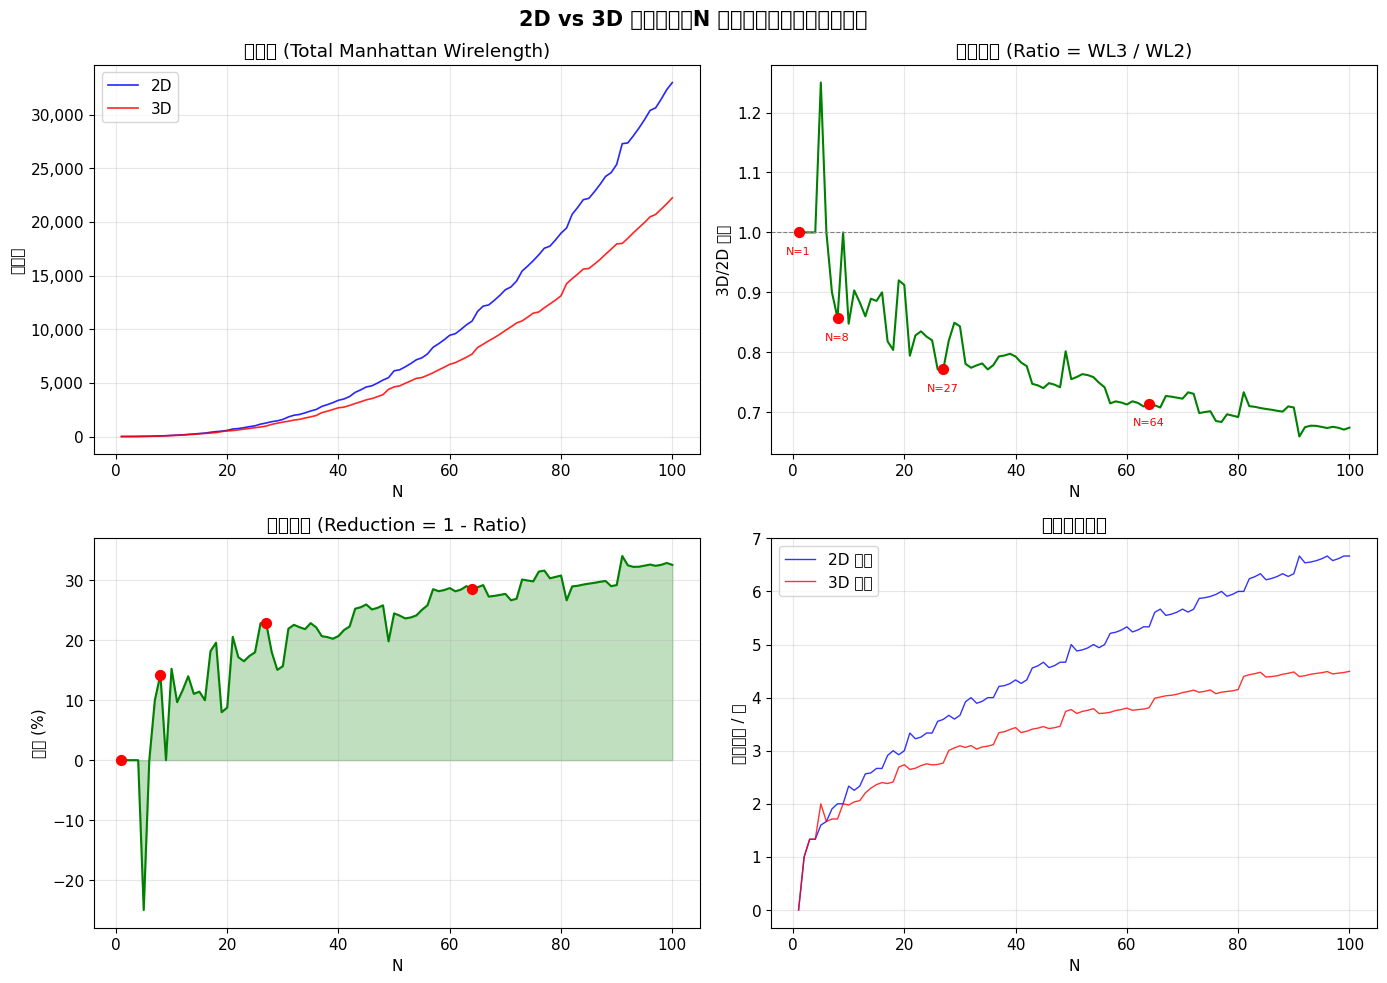

In [7]:
Ns = df["N"].values
wl2 = df["wl_2d"].values
wl3 = df["wl_3d"].values
avg2 = df["avg_2d"].values
avg3 = df["avg_3d"].values
ratio = df["ratio"].values
reduction = df["reduction_pct"].values
cubes = [n for n in Ns if round(n**(1/3))**3 == n]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("2D vs 3D 线长对比（N 个全互连细胞，空间密铺）", fontsize=15, fontweight="bold")

# (a) 总线长
ax = axes[0, 0]
ax.plot(Ns, wl2, "b-", lw=1.2, alpha=0.85, label="2D")
ax.plot(Ns, wl3, "r-", lw=1.2, alpha=0.85, label="3D")
ax.set_xlabel("N"); ax.set_ylabel("总线长")
ax.set_title("总线长 (Total Manhattan Wirelength)")
ax.legend(); ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# (b) 比值
ax = axes[0, 1]
ax.plot(Ns, ratio, "g-", lw=1.5)
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
for cn in cubes:
    idx = cn - 1
    ax.scatter(cn, ratio[idx], c="red", s=50, zorder=5)
    if cn <= 30 or cn in [64]:
        ax.annotate(f"N={cn}", (cn, ratio[idx]), textcoords="offset points",
                     xytext=(0, -16), ha="center", fontsize=8, color="red")
ax.set_xlabel("N"); ax.set_ylabel("3D/2D 比值")
ax.set_title("线长比值 (Ratio = WL3 / WL2)")

# (c) 收益百分比
ax = axes[1, 0]
ax.fill_between(Ns, reduction, alpha=0.25, color="green")
ax.plot(Ns, reduction, "g-", lw=1.5)
for cn in cubes:
    ax.scatter(cn, reduction[cn-1], c="red", s=50, zorder=5)
ax.set_xlabel("N"); ax.set_ylabel("收益 (%)")
ax.set_title("线长收益 (Reduction = 1 - Ratio)")

# (d) 平均每条边线长
ax = axes[1, 1]
ax.plot(Ns, avg2, "b-", lw=1, alpha=0.8, label="2D 平均")
ax.plot(Ns, avg3, "r-", lw=1, alpha=0.8, label="3D 平均")
ax.set_xlabel("N"); ax.set_ylabel("平均线长 / 边")
ax.set_title("单边平均线长")
ax.legend()

plt.tight_layout()
plt.show()


## 6. 单点检视：指定 N 的布局详情

In [8]:
def inspect_n(n):
    p2 = pos_2d(n); p3 = pos_3d(n)
    r2, c2 = optimal_2d_dims(n); d1, d2, d3 = optimal_3d_dims(n)
    wl2 = total_wirelength(p2, manhattan_2d, n)
    wl3 = total_wirelength(p3, manhattan_3d, n)
    ratio_val = wl3 / wl2 if wl2 else 1
    reduction_val = (1 - ratio_val) * 100
    display(Markdown(f"""\
**N = {n}**
- 2D 网格：{r2}x{c2}（半周长 {r2+c2}），总线长 {wl2}
- 3D 盒子：{d1}x{d2}x{d3}，总线长 {wl3}
- 比值：{ratio_val:.4f}，收益：{reduction_val:.1f}%

**2D 坐标：** `{p2}`
**3D 坐标：** `{p3}`
"""))

inspect_n(8)


**N = 8**
- 2D 网格：2x4（半周长 6），总线长 56
- 3D 盒子：2x2x2，总线长 48
- 比值：0.8571，收益：14.3%

**2D 坐标：** `[(0, 0), (1, 0), (2, 0), (3, 0), (0, 1), (1, 1), (2, 1), (3, 1)]`
**3D 坐标：** `[(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 1, 0), (0, 0, 1), (1, 0, 1), (0, 1, 1), (1, 1, 1)]`


In [9]:
inspect_n(27)

**N = 27**
- 2D 网格：4x7（半周长 11），总线长 1260
- 3D 盒子：3x3x3，总线长 972
- 比值：0.7714，收益：22.9%

**2D 坐标：** `[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3)]`
**3D 坐标：** `[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (2, 1, 0), (0, 2, 0), (1, 2, 0), (2, 2, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1), (0, 1, 1), (1, 1, 1), (2, 1, 1), (0, 2, 1), (1, 2, 1), (2, 2, 1), (0, 0, 2), (1, 0, 2), (2, 0, 2), (0, 1, 2), (1, 1, 2), (2, 1, 2), (0, 2, 2), (1, 2, 2), (2, 2, 2)]`


## 7. 交互探索（拖动滑块）

In [10]:
try:
    from ipywidgets import interact, IntSlider
    interact(lambda n: inspect_n(n), n=IntSlider(min=1, max=100, step=1, value=8,
                                                  description="N"))
except ImportError:
    display(Markdown("> 需先安装 ipywidgets：`pip install ipywidgets`"))


interactive(children=(IntSlider(value=8, description='N', min=1), Output()), _dom_classes=('widget-interact',)…

## 8. 理论分析

### 临界现象

| N | 现象 |
|---|------|
| ≤ 4 | 2D 和 3D 等价（都可排成 2×2 平面，第三维冗余） |
| 5 | **负收益**！3D 退化为一维长线 1×1×5，不如 2D 的 2×3 矩形 |
| 7~8 | **突破点**：3D 首次排成 2×2×2 立方体，获得 ~14% 收益 |
| 9 | 收益归零——9=3×3 完美正方形，2D 已达最优 |
| 27 | 3×3×3 完美立方体 vs 4×7 矩形，收益 ~23% |
| 64 | **转折点**：64=8²=4³，既完美平方又完美立方。2D 8×8、3D 4×4×4，比值 0.71 |

### 周期性振荡

收益随 N 呈现**锯齿状振荡**：
- **谷值**落在完美平方数附近（N=4, 9, 16, 25...）——2D 排布已是最优正方形
- **峰值**落在"差一点就能排成正方体"的 N——3D 紧凑但 2D 被拉长

### 渐进趋势

当 $N \to \infty$：

$$\frac{W_{3D}}{W_{2D}} \sim N^{-1/6} \to 0$$

理论上 3D 的优势趋近于 100%，但 N=100 时实际只到 ~33%。
收敛速度由 $N^{-1/6}$ 主导，非常缓慢——要 $N \approx 10^6$ 才能达到 90% 收益。


---

*逻辑折叠几何 (Logic Folding Geometry) — 2D→3D 线长收益思想实验*
